#### Vision Transformers Explained Series

# Position Embeddings for Vision Transformers, Explained

### The Math and the Code Behind Position Embeddings in Vision Transformers

*Since their introduction in 2017 with* Attention is All You Need¹, *transformers have established themselves as the state of the art for natural language processing (NLP). In 2021,* An Image is Worth 16x16 Words *successfully adapted transformers for computer vision tasks. Since then, numerous transformer-based architectures have been proposed for computer vision.*

**This article examines why position embeddings are a necessary component of vision transformers, and how different papers implement position embeddings. It includes open-source code for positional embeddings, as well as conceptual explanations. All of the code uses the PyTorch Python package.**

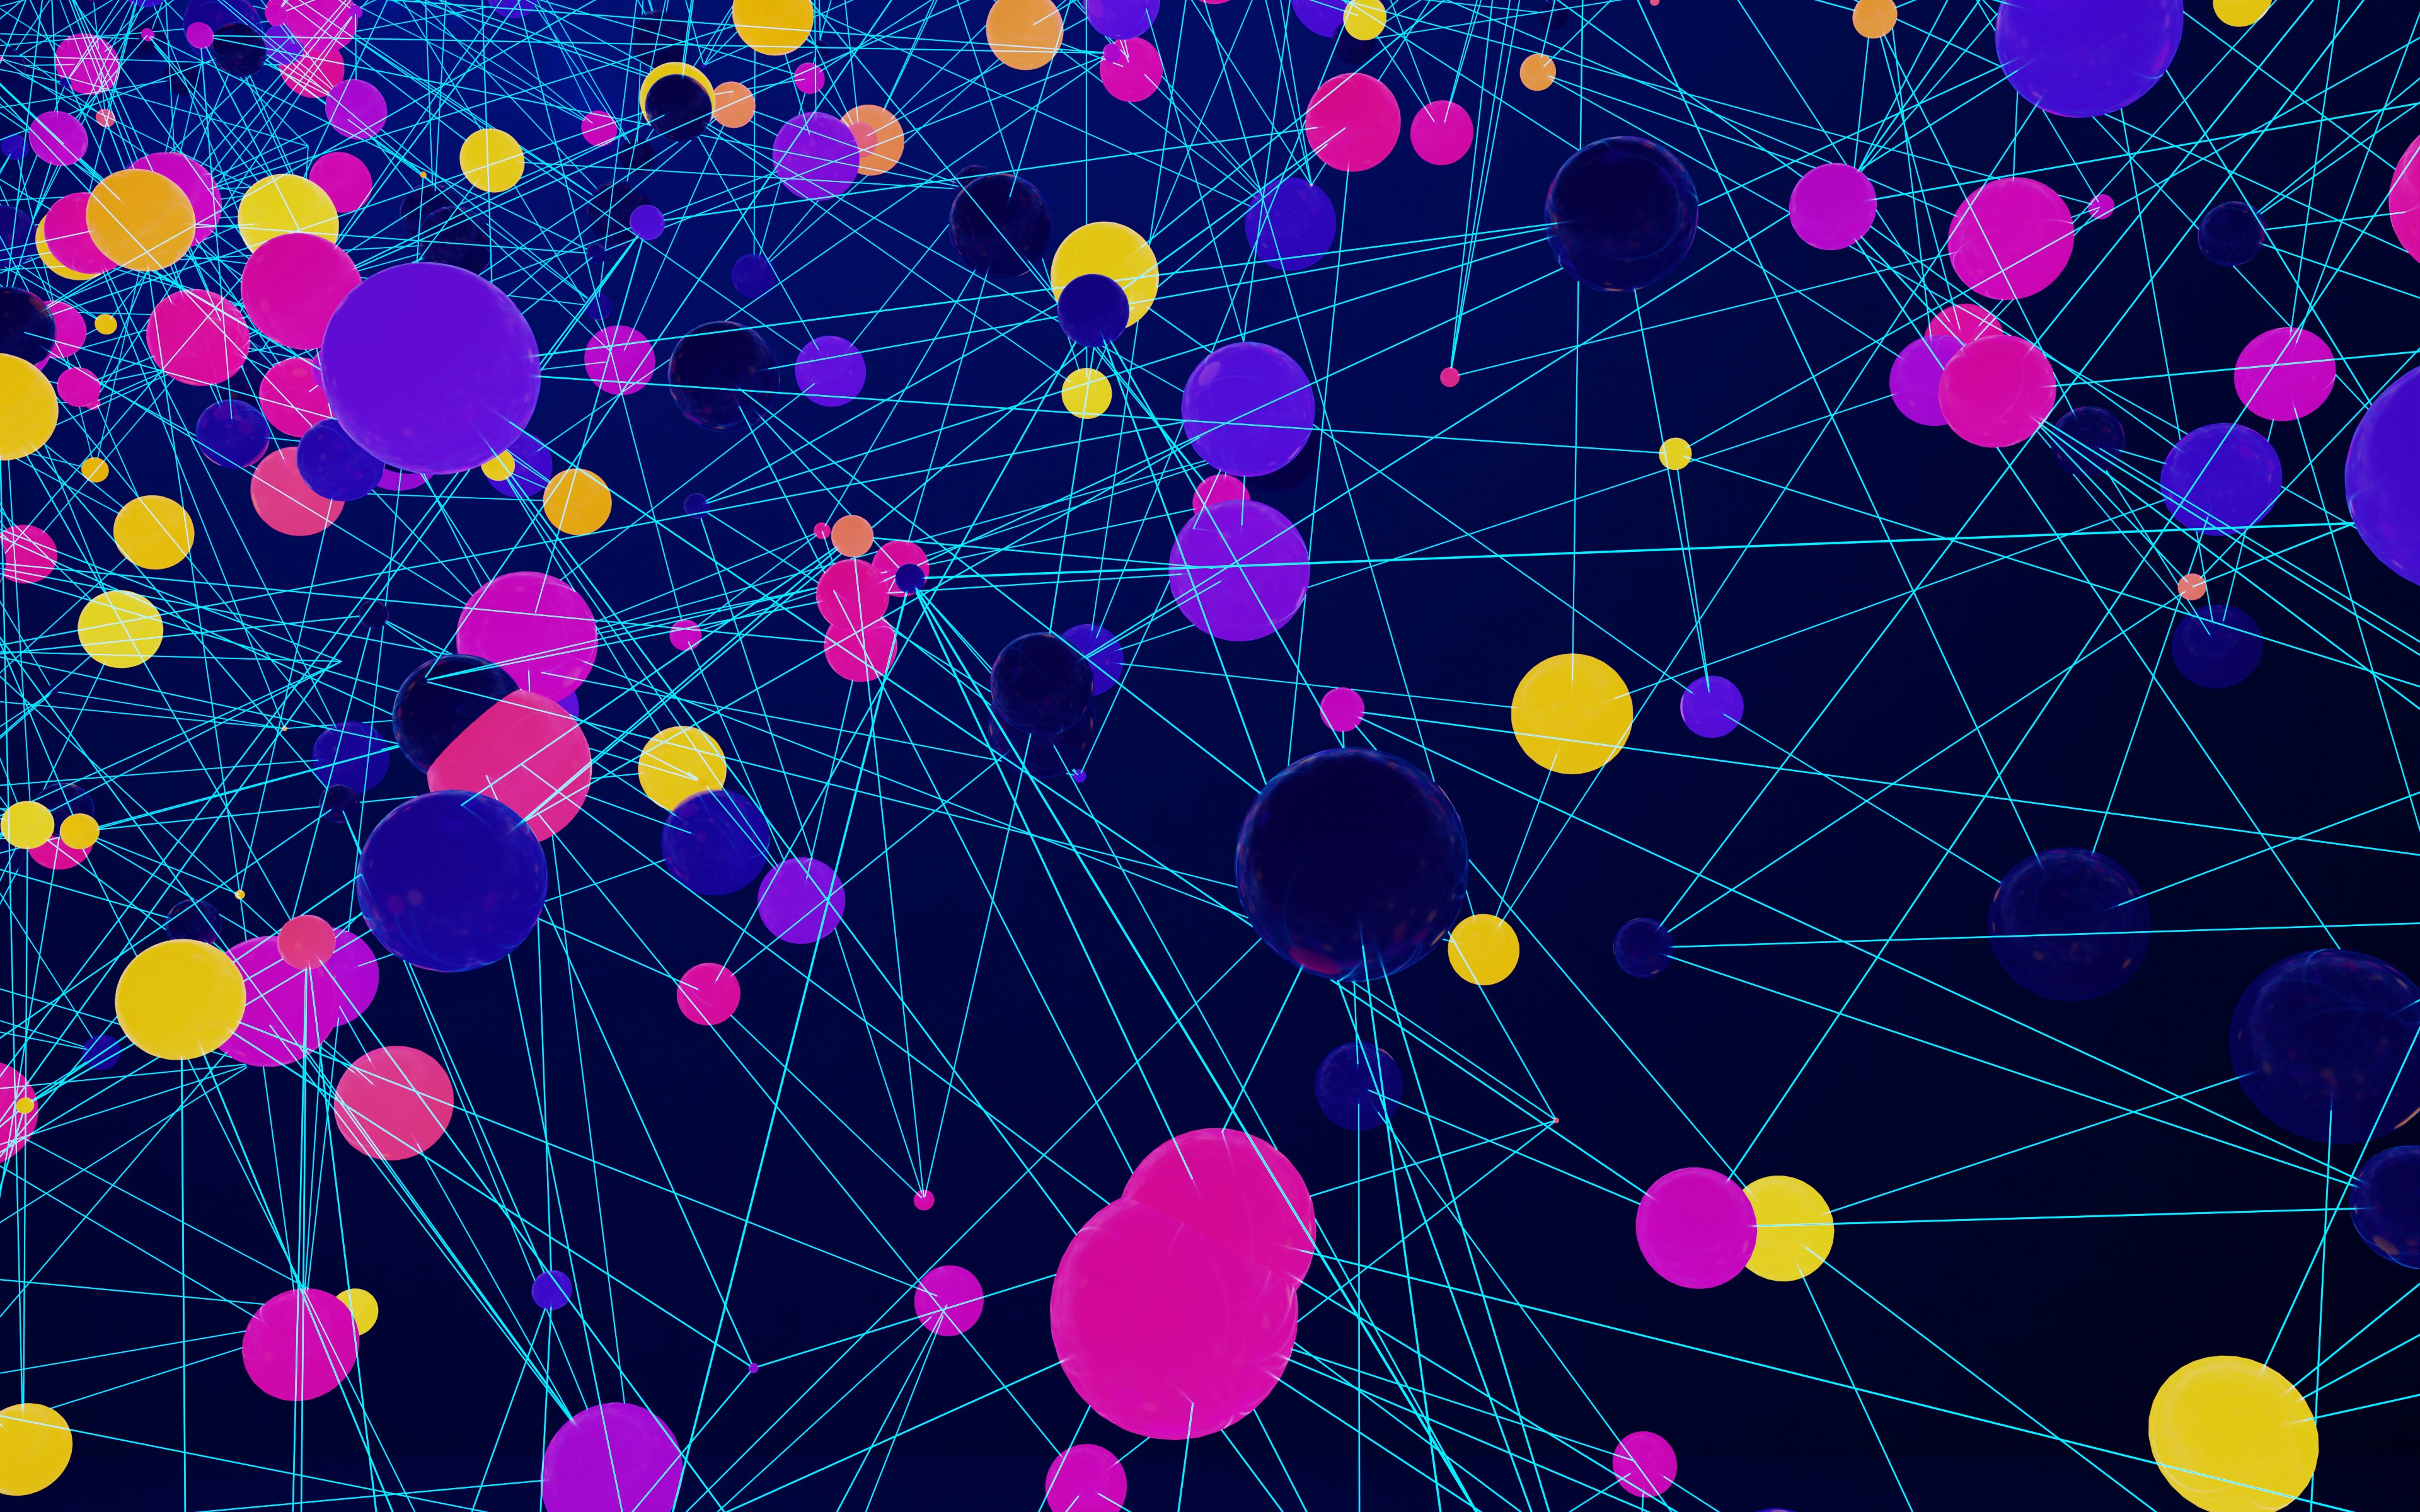

Photo by <a href="https://unsplash.com/@boliviainteligente?utm_content=creditCopyText&utm_medium=referral&utm_source=unsplash">BoliviaInteligente</a> on <a href="https://unsplash.com/photos/a-large-group-of-colorful-balls-floating-in-the-air-AXNZb4FEkh8?utm_content=creditCopyText&utm_medium=referral&utm_source=unsplash">Unsplash</a>

This article is part of a collection examining the internal workings of Vision Transformers in depth. Each of these articles is also available as a Jupyter Notebook with executable code. The other articles in the series are:

 - [Vision Transformers, Explained](https://towardsdatascience.com/vision-transformers-explained-a9d07147e4c8)
    - [Jupyter Notebook](https://github.com/lanl/vision_transformers_explained/blob/main/notebooks/VisionTransformersExplained.ipynb)
 - [Attention for Vision Transformers, Explained](https://towardsdatascience.com/attention-for-vision-transformers-explained-70f83984c673)
    - [Jupyter Notebook](https://github.com/lanl/vision_transformers_explained/blob/main/notebooks/AttentionExplained.ipynb)
 - [Position Embeddings for Vision Transformers, Explained](https://towardsdatascience.com/position-embeddings-for-vision-transformers-explained-a6f9add341d5)
    - [**Jupyter Notebook**](https://github.com/lanl/vision_transformers_explained/blob/main/notebooks/PositionEmbeddingExplained.ipynb)
 - [Tokens-to-Token Vision Transformers, Explained](https://towardsdatascience.com/tokens-to-token-vision-transformers-explained-2fa4e2002daa)
    - [Jupyter Notebook](https://github.com/lanl/vision_transformers_explained/blob/main/notebooks/TokensToTokenViTExplained.ipynb)
 - [GitHub Repository](https://github.com/lanl/vision_transformers_explained) for Vision Transformers, Explained Series

In [1]:
import os
import copy
import math
import typing
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch

In [2]:
figure_path = '../figures/NotebookOutput'

## Why Use Position Embeddings?

*Attention is All You Need*¹ states that transformers, due to their lack of recurrence or convolution, are not capable of learning information about the order of a set of tokens. Without a position embedding, transformers are invariant to the order of the tokens. For images, that means that patches of an image can be scrambled without impacting the predicted output.

Let's look at an example of patch order on this pixel art *Mountain at Dusk* by Luis Zuno (@ansimuz)³. The original artwork has been cropped and converted to a single channel image. This means that each pixel has a value between zero and one. Single channel images are typically displayed in grayscale; however, we'll be displaying it in a purple color scheme because its easier to see.

In [3]:
mountains = np.load(os.path.join(figure_path, 'mountains.npy'))

H = mountains.shape[0]
W = mountains.shape[1]
print('Mountain at Dusk is H =', H, 'and W =', W, 'pixels.')
print('\n')

fig = plt.figure(figsize=(10,6))
plt.imshow(mountains, cmap='Purples_r')
plt.xticks(np.arange(-0.5, W+1, 10), labels=np.arange(0, W+1, 10))
plt.yticks(np.arange(-0.5, H+1, 10), labels=np.arange(0, H+1, 10))
plt.clim([0,1])
cbar_ax = fig.add_axes([0.95, .11, 0.05, 0.77])
plt.clim([0, 1])
plt.colorbar(cax=cbar_ax);
#plt.savefig(os.path.join(figure_path, 'mountains.png'), bbox_inches='tight')

We can split this image up into patches of size 20. (For a more in depth explanation of splitting images into patches, see the [Vision Transformers article](https://towardsdatascience.com/vision-transformers-explained-a9d07147e4c8).)

In [4]:
P = 20
N = int((H*W)/(P**2))
print('There will be', N, 'patches, each', P, 'by', str(P)+'.')
print('\n')

fig = plt.figure(figsize=(10,6))
plt.imshow(mountains, cmap='Purples_r')
plt.clim([0,1])
plt.hlines(np.arange(P, H, P)-0.5, -0.5, W-0.5, color='w')
plt.vlines(np.arange(P, W, P)-0.5, -0.5, H-0.5, color='w')
plt.xticks(np.arange(-0.5, W+1, 10), labels=np.arange(0, W+1, 10))
plt.yticks(np.arange(-0.5, H+1, 10), labels=np.arange(0, H+1, 10))
x_text = np.tile(np.arange(9.5, W, P), 3)
y_text = np.repeat(np.arange(9.5, H, P), 5)
for i in range(1, N+1):
    plt.text(x_text[i-1], y_text[i-1], str(i), color='w', fontsize='xx-large', ha='center')
plt.text(x_text[2], y_text[2], str(3), color='k', fontsize='xx-large', ha='center');
#plt.savefig(os.path.join(figure_path, 'mountain_patches.png'), bbox_inches='tight')

The claim is that vision transformers would be unable to distinguish the original image with a version where the patches had been scrambled.

In [5]:
np.random.seed(21)
scramble_order = np.random.permutation(N)
left_x = np.tile(np.arange(0, W-P+1, 20), 3)
right_x = np.tile(np.arange(P, W+1, 20), 3)
top_y = np.repeat(np.arange(0, H-P+1, 20), 5)
bottom_y = np.repeat(np.arange(P, H+1, 20), 5)

scramble = np.zeros_like(mountains)
for i in range(N):
    t = scramble_order[i]
    scramble[top_y[i]:bottom_y[i], left_x[i]:right_x[i]] = mountains[top_y[t]:bottom_y[t], left_x[t]:right_x[t]]
    
fig = plt.figure(figsize=(10,6))
plt.imshow(scramble, cmap='Purples_r')
plt.clim([0,1])
plt.hlines(np.arange(P, H, P)-0.5, -0.5, W-0.5, color='w')
plt.vlines(np.arange(P, W, P)-0.5, -0.5, H-0.5, color='w')
plt.xticks(np.arange(-0.5, W+1, 10), labels=np.arange(0, W+1, 10))
plt.yticks(np.arange(-0.5, H+1, 10), labels=np.arange(0, H+1, 10))
x_text = np.tile(np.arange(9.5, W, P), 3)
y_text = np.repeat(np.arange(9.5, H, P), 5)
for i in range(N):
    plt.text(x_text[i], y_text[i], str(scramble_order[i]+1), color='w', fontsize='xx-large', ha='center')
    
i3 = np.where(scramble_order==2)[0][0]
plt.text(x_text[i3], y_text[i3], str(scramble_order[i3]+1), color='k', fontsize='xx-large', ha='center');
#plt.savefig(os.path.join(figure_path, 'mountain_scrambled_patches.png'), bbox_inches='tight')

Obviously, this is a very different image from the original, and you wouldn't want a vision transformer to treat these two images as the same.

## Attention Invariance Up to Permutation

Let's investigate the claim that vision transformers are invariant to the order of the tokens. The component of the transformer that would be invariant to token order is the attention module. While an in depth explanation of the attention module is not the focus of this article, a basis understanding is required. For a more detailed walk through of attention in vision transformers, see the [Attention Article](https://towardsdatascience.com/attention-for-vision-transformers-explained-70f83984c673).

Attention is computed from three matrices - **Q**ueries, **K**eys, and **V**alues - each generated from passing the tokens through a linear layer. Once the Q, K, and V matrices are generated, attention is computed using the following formula.

$$Attention(Q, K, V) = softmax(\frac{Q*K^T}{\sqrt{d_k}})*V$$

where $Q$, $K$, $V$, are the queries, keys, and values, respectively; and $d_k$ is a scaling value. To demonstrate the invariance of attention to token order, we'll start with three randomly generated matrices to represent Q, K, and V. The shape of Q, K, and V is as follows:

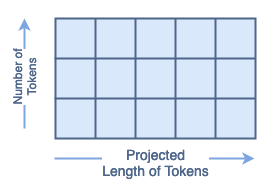

We'll use 4 tokens of projected length 9 in this example. The matrices will contain integers to avoid floating point multiplication errors. Once generated, we'll switch the position of token 0 and token 2 in all three matrices. Matrices with swapped tokens will be denoted with a subscript *s*.

In [6]:
def mat_plot(matrix, title):
    up_clim = max(np.abs(matrix.flatten()))
    low_clim = min(np.abs(matrix.flatten()))
    y, x = matrix.shape
    im = plt.imshow(matrix, cmap='viridis')
    plt.xticks(ticks=np.arange(x));
    plt.yticks(ticks=np.arange(y));
    plt.title(title)
    plt.vlines(np.arange(0.5, x-0.5, 1), -0.5, y-0.5, colors='#DDDDDD')
    plt.hlines(np.arange(0.5, y-0.5, 1), -0.5, x-0.5, colors='#DDDDDD')

    ## Adding Value Labels
    for i in range(y):
        for j in range(x):
            if matrix[i,j]==0: #Don't label if it's zero
                pass
            elif np.abs(matrix[i,j]) > low_clim + ((up_clim-low_clim)/2):
                plt.text(j, i, round(matrix[i, j], 2), ha='center', va='center', color='k', fontsize=12)
            else:
                plt.text(j, i, round(matrix[i, j], 2), ha='center', va='center', color='w', fontsize=12)


In [7]:
n_tokens = 4
l_tokens = 9
shape = n_tokens, l_tokens
mx = 20 #max integer for generated matricies

# Generate Normal Matricies
np.random.seed(21)
Q = np.random.randint(1, mx, shape)
K = np.random.randint(1, mx, shape)
V = np.random.randint(1, mx, shape)

# Generate Row-Swapped Matricies
swapQ = copy.deepcopy(Q)
swapQ[[0, 2]] = swapQ[[2, 0]]
swapK = copy.deepcopy(K)
swapK[[0, 2]] = swapK[[2, 0]]
swapV = copy.deepcopy(V)
swapV[[0, 2]] = swapV[[2, 0]]

# Plot Matricies
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(8,8))
fig.tight_layout(pad=2.0)
plt.subplot(3, 2, 1)
mat_plot(Q, 'Q')
plt.subplot(3, 2, 2)
mat_plot(swapQ, r'$Q_S$')
plt.subplot(3, 2, 3)
mat_plot(K, 'K')
plt.subplot(3, 2, 4)
mat_plot(swapK, r'$K_S$')
plt.subplot(3, 2, 5)
mat_plot(V, 'V')
plt.subplot(3, 2, 6)
mat_plot(swapV, r'$V_S$')
#plt.savefig(os.path.join(figure_path, 'randominteger_QKV.png'), bbox_inches='tight')

The first matrix multiplication in the attention formula is $Q*K^T=A$, where the resulting matrix $A$ is a square with size equal to the number of tokens. When we compute $A_s$ with $Q_s$ and $K_s^T$, the resulting $A_s$ has both rows [0, 2] and columns [0,2] swapped from A.

In [8]:
A = Q @ K.transpose()
swapA = swapQ @ swapK.transpose()
modA = copy.deepcopy(A)
modA[[0,2]] = modA[[2,0]] #swap rows
modA[:, [2, 0]] = modA[:, [0, 2]] #swap cols

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8,3))
fig.tight_layout(pad=1.0)
plt.subplot(1, 3, 1)
mat_plot(A, r'$A = Q*K^T$')
plt.subplot(1, 3, 2)
mat_plot(swapA, r'$A_S = Q_S * K_S^T$')
plt.subplot(1, 3, 3)
mat_plot(modA, 'A\nwith rows [0,2] swaped\n and cols [0,2] swaped')
#plt.savefig(os.path.join(figure_path, 'AQKs.png'), bbox_inches='tight')

The next matrix multiplication is $A*V=A$, where the resulting matrix $A$ has the same shape as the initial $Q$, $K$, and $V$ matrices. When we compute $A_s$ with $A_s$ and $V_s$, the resulting $A_s$ has rows [0,2] swapped from A.

In [9]:
A = A @ V
swapA = swapA @ swapV
modA = copy.deepcopy(A)
modA[[0,2]] = modA[[2,0]] #swap rows

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 7))
fig.tight_layout(pad=1.0)
plt.subplot(2, 2, 1)
mat_plot(A, r'$A = A*V$')
plt.subplot(2, 2, 2)
mat_plot(swapA, r'$A_S = A_S * V_S$')
plt.subplot(2, 2, 4)
mat_plot(modA, 'A\nwith rows [0,2] swaped')
axs[1,0].axis('off');
#plt.savefig(os.path.join(figure_path, 'AVAs.png'), bbox_inches='tight')

This demonstrates that changing the order of the tokens in the input to an attention layer results in an output attention matrix with the same token rows changed. This remains intuitive, as attention is a computation of the relationship between the tokens. Without position information, changing the token order does not change how the tokens are related. It isn't obvious to me why this permutation of the output isn't enough information to convey position to the transformers. However, everything I've read says that it isn't enough, so we accept that and move forward.

## Position Embeddings in Literature

In addition to the theoretically justification for positional embeddings, models that utilize position embeddings perform with higher accuracy than models without. However, there isn't clear evidence supporting one type of position embedding over another.

In *Attention is All You Need*¹, they use a fixed sinusoidal positional embedding. They note that they experimented with a learned positional embedding, but observed "nearly identical results." Note that this model was designed for NLP applications, specifically translation. The authors proceeded with the fixed embedding because it allowed for varying phrase lengths. This would likely not be a concern in computer vision applications.

In *An Image is Worth 16x16 Words*², they apply positional embeddings to images. They run ablation studies on four different position embeddings in both fixed and learnable settings. This study encompasses no position embedding, a 1D position embedding, a 2D position embedding, and a relative position embedding. They find that models with a position embedding significantly outperform models without a position embedding. However, there is little difference between their different types of positional embeddings or between the fixed and learnable embeddings. This is congruent with the results in [1] that a position embedding is beneficial, though the exact embedding chosen is of little consequence.

In *Tokens-to-Token ViT: Training Vision Transformers from Scratch on ImageNet*⁴, they use a sinusoidal position embedding that they describe as being the same as in [2]. Their released code mirrors the equations for the sinusoidal position embedding in [1]. Furthermore, their released code fixes the position embedding rather than letting it be a learned parameter with a sinusoidal initialization.

## An Example Position Embedding

### Defining the Position Embedding

Now, we can look at the specifics of a sinusoidal position embedding. The code is based on the publicly available GitHub code for *Tokens-to-Token ViT*⁴. Functionally, the position embedding is a matrix with the same shape as the tokens. This looks like:

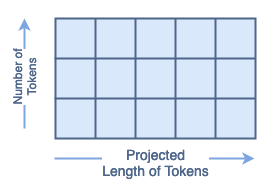

The formulae for the sinusoidal position embedding from [1] look like

$$\theta_{ij} = \frac{i}{10,000^{2jd^{-1}}}$$

$$PE_{(i, 2j)} = sin(\theta_{ij})$$

$$PE_{(i, 2j+1)} = cos(\theta_{ij})$$

where $PE$ is the position embedding matrix, $i$ is along the number of tokens, $j$ is along the length of the tokens, and $d$ is the token length.

In code, that looks like

In [10]:
def get_sinusoid_encoding(num_tokens, token_len):
    """ Make Sinusoid Encoding Table

        Args:
            num_tokens (int): number of tokens
            token_len (int): length of a token
            
        Returns:
            (torch.FloatTensor) sinusoidal position encoding table
    """

    def get_position_angle_vec(i):
        return [i / np.power(10000, 2 * (j // 2) / token_len) for j in range(token_len)]

    sinusoid_table = np.array([get_position_angle_vec(i) for i in range(num_tokens)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2]) 

    return torch.FloatTensor(sinusoid_table).unsqueeze(0)

Let's generate an example position embedding matrix. We'll use 176 tokens. Each token has length 768, which is the default in the T2T-ViT⁴ code. Once the matrix is generated, we can plot it.

In [11]:
PE = get_sinusoid_encoding(num_tokens=176, token_len=768)

In [12]:
fig = plt.figure(figsize=(10, 8))
plt.imshow(PE[0, :, :], cmap='PuOr_r')
plt.xlabel('Along Length of Token')
plt.ylabel('Individual Tokens');
cbar_ax = fig.add_axes([0.95, .36, 0.05, 0.25])
plt.clim([-1, 1])
plt.colorbar(label='Value of Position Encoding', cax=cbar_ax);
#plt.savefig(os.path.join(figure_path, 'fullPE.png'), bbox_inches='tight')

Let's zoom in to the beginning of the tokens.

In [13]:
fig = plt.figure()
plt.imshow(PE[0, :, 0:301], cmap='PuOr_r')
plt.xlabel('Along Length of Token')
plt.ylabel('Individual Tokens');
cbar_ax = fig.add_axes([0.95, .2, 0.05, 0.6])
plt.clim([-1, 1])
plt.colorbar(label='Value of Position Encoding', cax=cbar_ax);
#plt.savefig(os.path.join(figure_path, 'zoomedinPE.png'), bbox_inches='tight')

It certainly has a sinusoidal structure!

### Applying Position Embedding to Tokens

Now, we can add our position embedding to our tokens! We're going to use Mountain at Dusk³ with the same patch tokenization as above. That will give us 15 tokens of length $20^2=400$. For more detail about patch tokenization, see the [Vision Transformers article](https://towardsdatascience.com/vision-transformers-explained-a9d07147e4c8). Recall that the patches look like:

In [14]:
fig = plt.figure(figsize=(10,6))
plt.imshow(mountains, cmap='Purples_r')
plt.hlines(np.arange(P, H, P)-0.5, -0.5, W-0.5, color='w')
plt.vlines(np.arange(P, W, P)-0.5, -0.5, H-0.5, color='w')
plt.xticks(np.arange(-0.5, W+1, 10), labels=np.arange(0, W+1, 10))
plt.yticks(np.arange(-0.5, H+1, 10), labels=np.arange(0, H+1, 10))
x_text = np.tile(np.arange(9.5, W, P), 3)
y_text = np.repeat(np.arange(9.5, H, P), 5)
for i in range(1, N+1):
    plt.text(x_text[i-1], y_text[i-1], str(i), color='w', fontsize='xx-large', ha='center')
plt.text(x_text[2], y_text[2], str(3), color='k', fontsize='xx-large', ha='center')
cbar_ax = fig.add_axes([0.95, .11, 0.05, 0.77])
plt.clim([0, 1])
plt.colorbar(cax=cbar_ax);
#plt.savefig(os.path.join(figure_path, 'mountain_patches_w_colorbar.png'), bbox_inches='tight')

When we convert those patches into tokens, it looks like:

In [15]:
patch = np.zeros((P,P))
tokens = np.zeros((N, P**2))
for i in range(N):
    patch = mountains[top_y[i]:bottom_y[i], left_x[i]:right_x[i]]
    tokens[i, :] = patch.flatten()

fig = plt.figure(figsize=(10,6))
plt.imshow(tokens, aspect=5, cmap='Purples_r')
plt.xlabel('Length of Tokens')
plt.ylabel('Number of Tokens')
cbar_ax = fig.add_axes([0.95, .36, 0.05, 0.25])
plt.clim([0, 1])
plt.colorbar(cax=cbar_ax);
#plt.savefig(os.path.join(figure_path, 'mountain_tokens_matrix.png'), bbox_inches='tight')

Now, we can make a position embedding in the correct shape:

In [16]:
PE = get_sinusoid_encoding(num_tokens=15, token_len=400).numpy()[0,:,:]
fig = plt.figure(figsize=(10,6))
plt.imshow(PE, aspect=5, cmap='PuOr_r')
plt.xlabel('Length of Tokens')
plt.ylabel('Number of Tokens')
cbar_ax = fig.add_axes([0.95, .36, 0.05, 0.25])
plt.clim([-1, 1])
plt.colorbar(cax=cbar_ax);
#plt.savefig(os.path.join(figure_path, 'mountainsPE.png'), bbox_inches='tight')

We're ready now to add the position embedding to the tokens. Purple areas in the position embedding will make the tokens darker, while orange areas will make them lighter.

In [17]:
mountainsPE = tokens + PE
rescaled_mountainsPE = (mountainsPE - np.min(mountainsPE)) / (np.max(mountainsPE) - np.min(mountainsPE))

fig = plt.figure(figsize=(10,6))
plt.imshow(rescaled_mountainsPE, aspect=5, cmap='Purples_r')
plt.xlabel('Length of Tokens')
plt.ylabel('Number of Tokens')
cbar_ax = fig.add_axes([0.95, .36, 0.05, 0.25])
plt.clim([0, 1])
plt.colorbar(cax=cbar_ax);
#plt.savefig(os.path.join(figure_path, 'mountains_plus_PE.png'), bbox_inches='tight')

You can see the structure from the original tokens, as well as the structure in the position embedding! Both pieces of information are present to be passed forward into the transformer.

## Conclusion

Now, you should have some intuition of how position embeddings help vision transformers learn. The code associated with this article can be found in the [Github Repository](https://github.com/lanl/vision_transformers_explained) for this series. The code from the T2T-ViT paper⁴ can be found [here](https://github.com/yitu-opensource/T2T-ViT). Happy transforming!

This article was approved for release by Los Alamos National Laboratory as LA-UR-23–33876. The associated code was approved for a BSD-3 open source license under O#4693.

### Further Reading

To learn more about position embeddings in NLP contexts, see
 - A Gentle Introduction to Positional Encoding in Transformer Models: https://machinelearningmastery.com/a-gentle-introduction-to-positional-encoding-in-transformer-models-part-1/

For a video lecture broadly about vision transformers (with relevant chapters noted), see
 - Vision Transformer and its Applications: https://youtu.be/hPb6A92LROc?si=GaGYiZoyDg0PcdSP 
      - Vision Transformer is Invariant to Position of Patches 10:44–12:52 (https://youtu.be/hPb6A92LROc?t=644&si=Keu-5i9BQ5c69mxz)
      - Position Embedding 12:52–14:15 (https://youtu.be/hPb6A92LROc?t=772&si=spdlYZl-TRgbGgzn)

### Citations

[1] Vaswani et al (2017). Attention Is All You Need. https://doi.org/10.48550/arXiv.1706.03762

[2] Dosovitskiy et al (2020). An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale. https://doi.org/10.48550/arXiv.2010.11929

[3] Luis Zuno (@ansimuz). Mountain at Dusk Background. License CC0: https://opengameart.org/content/mountain-at-dusk-background

[4] Yuan et al (2021). Tokens-to-Token ViT: Training Vision Transformers from Scratch on ImageNet. https://doi.org/10.48550/arXiv.2101.11986
 - GitHub code: https://github.com/yitu-opensource/T2T-ViT